In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



In [2]:
# Load data
df = pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv")
# (rows, columns)
print(df.shape) 
df.head()

(16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Shape and column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [4]:
# Missing values per column
print("\nMissing values per column:")
df.isna().sum().sort_values(ascending=False)


Missing values per column:


User_Count         9129
Critic_Score       8582
Critic_Count       8582
Rating             6769
User_Score         6704
Developer          6623
Year_of_Release     269
Publisher            54
Name                  2
Genre                 2
Platform              0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
dtype: int64

In [5]:
# target value
Critic_Score = df['Critic_Score'].describe()
User_Score = df['User_Score'].describe()
print(Critic_Score)
print(User_Score)

count    8137.000000
mean       68.967679
std        13.938165
min        13.000000
25%        60.000000
50%        71.000000
75%        79.000000
max        98.000000
Name: Critic_Score, dtype: float64
count     10015
unique       96
top         tbd
freq       2425
Name: User_Score, dtype: object


In [6]:
# Convert User_Score to numeric; 'tbd' becomes NaN
df['User_Score_Clean'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Create a 0–100 style same as Critic_Score
df['User_Rating'] = df['User_Score_Clean'] * 10

# Check how many ratings we have
print("Fraction of rows with user rating:",
      1 - df['User_Rating'].isna().mean())

df[['Name', 'Platform', 'User_Score', 'User_Score_Clean', 'User_Rating']].head()



Fraction of rows with user rating: 0.4539745200071774


,Name,Platform,User_Score,User_Score_Clean,User_Rating
0,Wii Sports,Wii,8,8.0,80.0
1,Super Mario Bros.,NES,NaN,NaN,NaN
2,Mario Kart Wii,Wii,8.3,8.3,83.0
3,Wii Sports Resort,Wii,8,8.0,80.0
4,Pokemon Red/Pokemon Blue,GB,NaN,NaN,NaN


In [7]:
df_model = df.dropna(subset=['User_Rating'])
print("Shape after keeping games with user ratings:", df_model.shape)


Shape after keeping games with user ratings: (7590, 18)


In [8]:
# Map the ESRB rating to age group
def map_age_group(r):
    if r in ['E', 'EC', 'K-A']:
        return 'Kids'
    elif r in ['E10+']:
        return 'Teens'
    elif r in ['T']:
        return 'Teens'
    elif r in ['M', 'AO']:
        return 'Adults'
    else:
        return 'All Ages'   # RP, missing, or unknown

df['Age_Group_Targeted'] = df['Rating'].apply(map_age_group)


In [17]:
# Numeric summary + distributions
num_cols = [
    'User_Rating',
    'Critic_Score',
    'Critic_Count',
    'User_Count',
    'Year_of_Release',
    'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'
]
df[num_cols].describe()

,User_Rating,Critic_Score,Critic_Count,User_Count,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,7590.000000,8137.000000,8137.000000,7590.000000,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000
mean,71.250461,68.967679,26.360821,162.229908,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543
std,15.000061,13.938165,18.980495,561.282326,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935
min,0.000000,13.000000,3.000000,4.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,64.000000,60.000000,12.000000,10.000000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,75.000000,71.000000,21.000000,24.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,82.000000,79.000000,36.000000,81.000000,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000
max,97.000000,98.000000,113.000000,10665.000000,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000


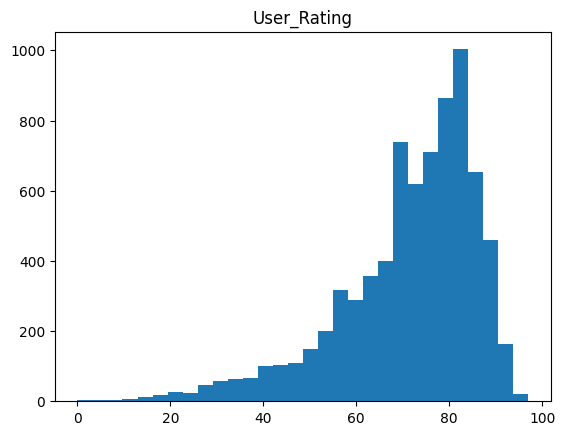

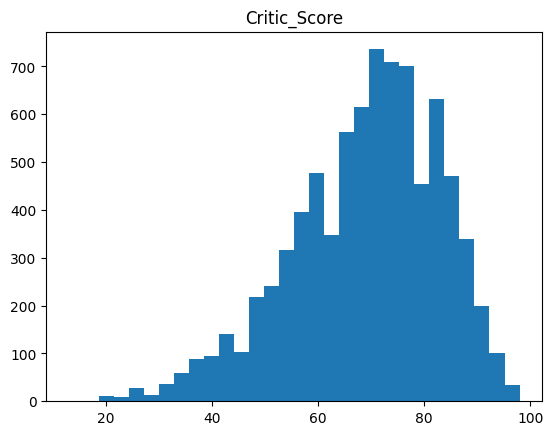

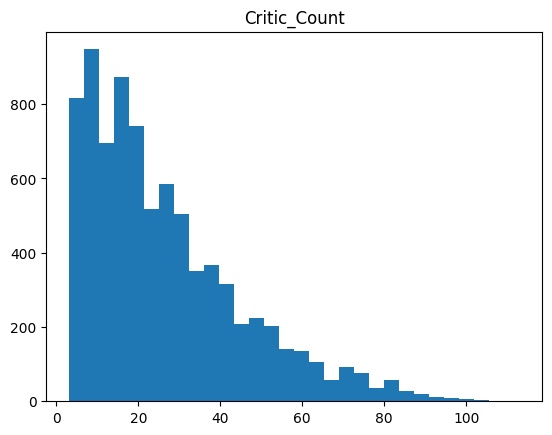

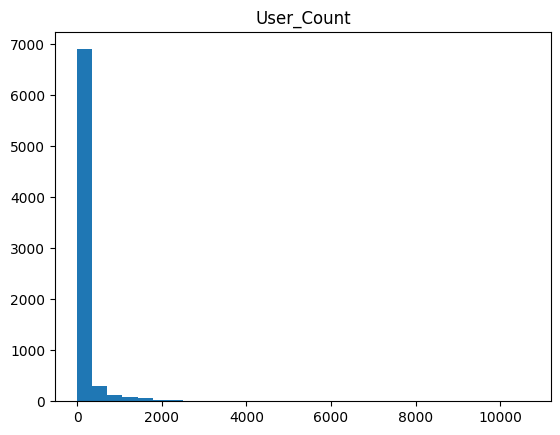

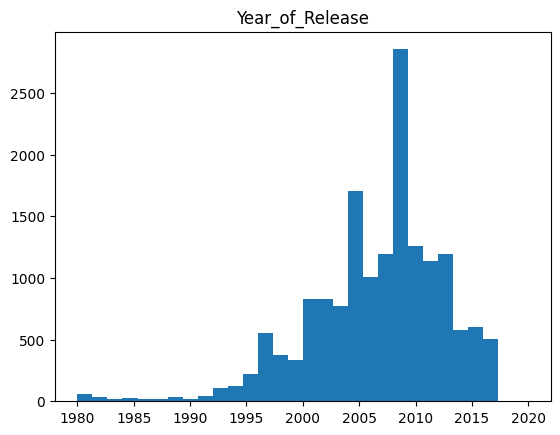

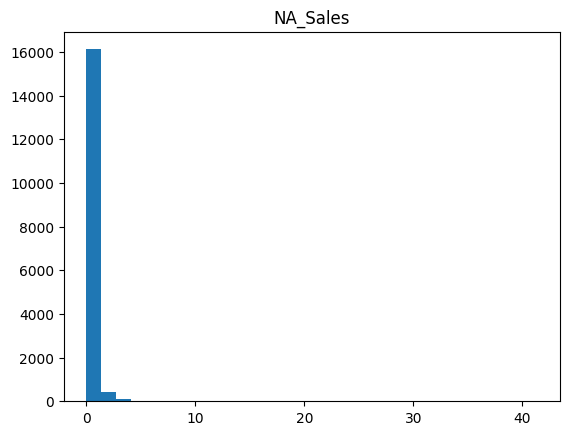

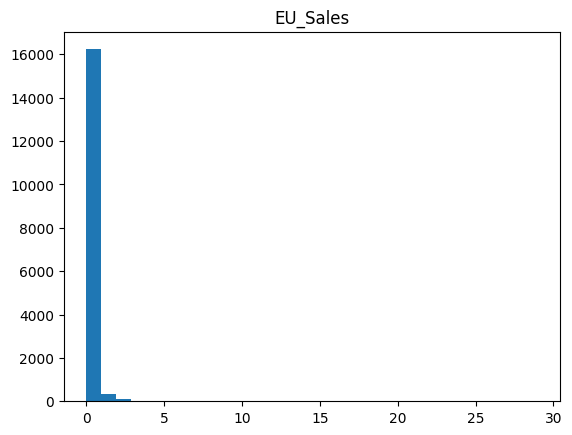

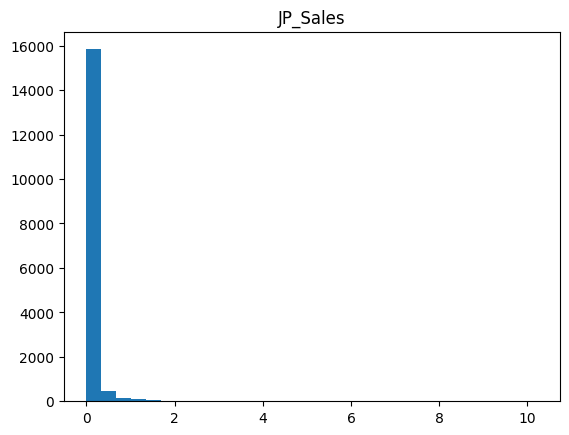

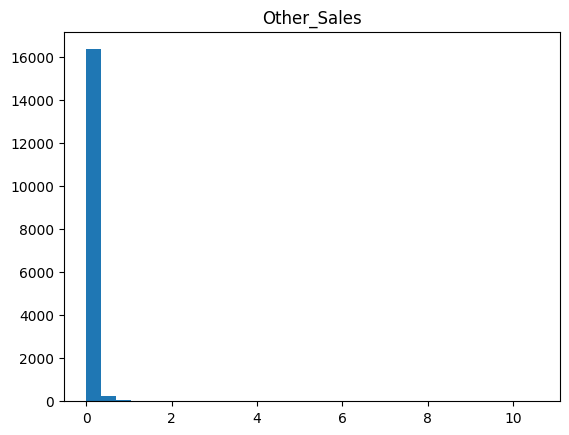

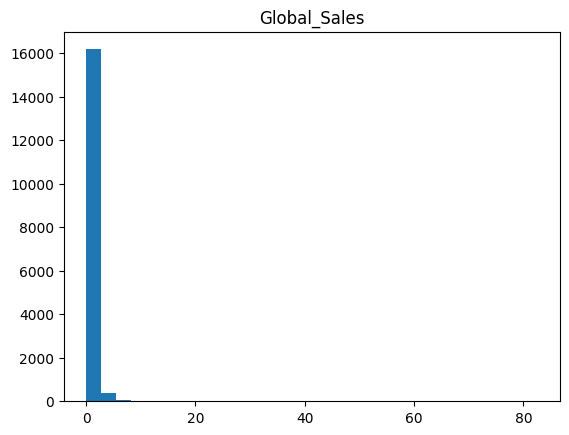

In [18]:
# Not using sales data since it need log_scale for it
num_cols = [
    'User_Rating',
    'Critic_Score',
    'Critic_Count',
    'User_Count',
    'Year_of_Release']

for col in num_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.show()


In [12]:
cat_cols = ['Platform', 'Genre', 'Publisher', 'Developer',
            'Rating', 'Age_Group_Targeted']

for col in cat_cols:
    print(f"\n=== {col} ===")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))



=== Platform ===
Unique values: 31
Platform
PS2     2161
DS      2152
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
Name: count, dtype: int64

=== Genre ===
Unique values: 12
Genre
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Name: count, dtype: int64

=== Publisher ===
Unique values: 581
Publisher
Electronic Arts                 1356
Activision                       985
Namco Bandai Games               939
Ubisoft                          933
Konami Digital Entertainment     834
THQ                              715
Nintendo                         706
Sony Computer Entertainment      687
Sega                             638
Take-Two Interactive             422
Name: count, dtype: int64

=== Developer ===
Unique values: 1696
Developer
Ubisoft             204
EA Spor

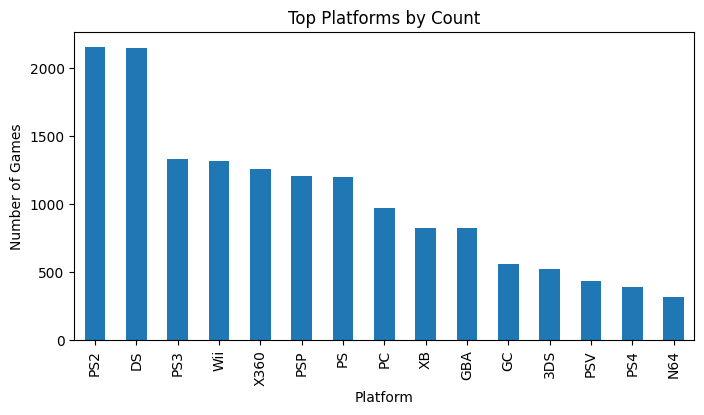

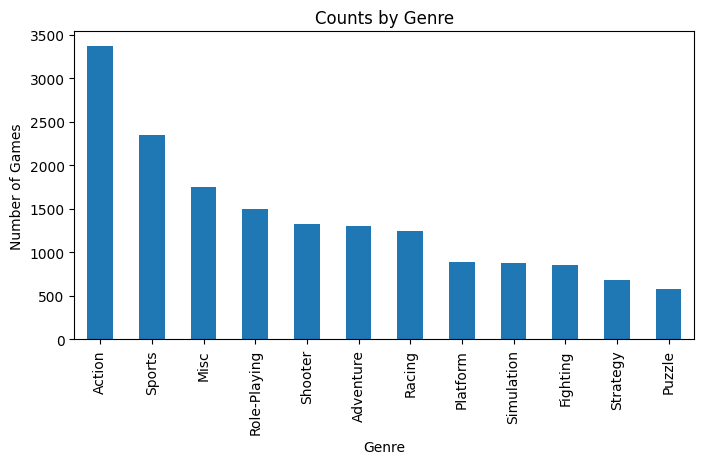

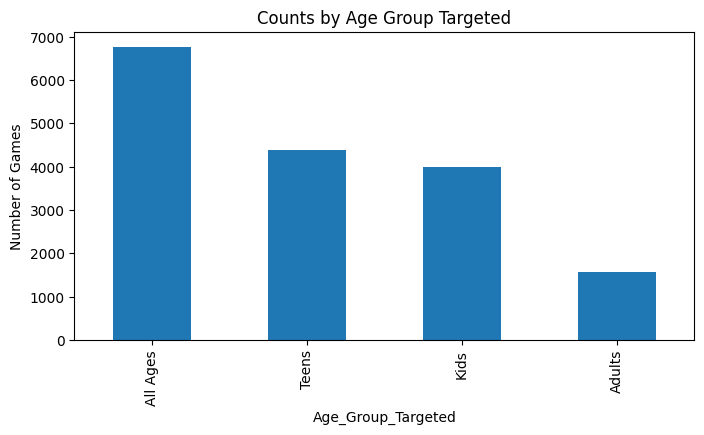

In [13]:
# Platform
df['Platform'].value_counts().head(15).plot(kind='bar', figsize=(8,4))
plt.title("Top Platforms by Count")
plt.ylabel("Number of Games")
plt.show()

# Genre
df['Genre'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Counts by Genre")
plt.ylabel("Number of Games")
plt.show()

# Age group (derived)
df['Age_Group_Targeted'].value_counts().plot(kind='bar' , figsize=(8,4))
plt.title("Counts by Age Group Targeted")
plt.ylabel("Number of Games")
plt.show()


User_Rating        1.000000
Critic_Score       0.580878
Critic_Count       0.194133
JP_Sales           0.125598
Global_Sales       0.088139
NA_Sales           0.086200
Other_Sales        0.057119
EU_Sales           0.055337
User_Count         0.027044
Year_of_Release   -0.267851
Name: User_Rating, dtype: float64


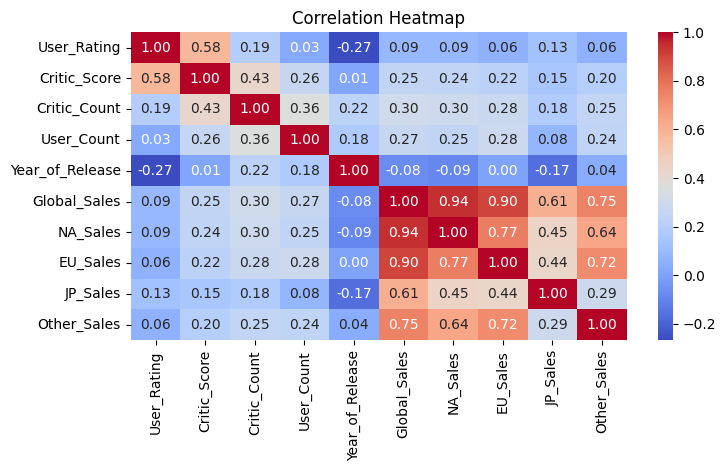

In [14]:
corr = df[['User_Rating',
           'Critic_Score',
           'Critic_Count',
           'User_Count',
           'Year_of_Release',
           'Global_Sales',
           'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()

print(corr['User_Rating'].sort_values(ascending=False))
plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Average User Rating by Genre (>= 50 games):
                   mean  count
Genre                         
Role-Playing  76.195155    743
Fighting      73.025063    399
Platform      73.014019    428
Strategy      72.951768    311
Puzzle        71.750000    128
Simulation    71.345930    344
Adventure     71.330000    300
Action        70.540437   1830
Shooter       70.418831    924
Racing        70.361934    641

Average User Rating by Platform (>= 50 games):
               mean  count
Platform                  
PS        78.654321    162
GBA       76.768627    255
PS2       76.268332   1241
GC        75.975410    366
XB        75.005119    586
PSV       73.363636    143
PSP       72.282660    421
PC        70.624675    770
DS        70.251938    516
WiiU      69.040000    100

Average User Rating by Age_Group_Targeted (>= 50 games):
                         mean  count
Age_Group_Targeted                  
Teens               71.618479   3604
Adults              71.608295   1519
Kids 

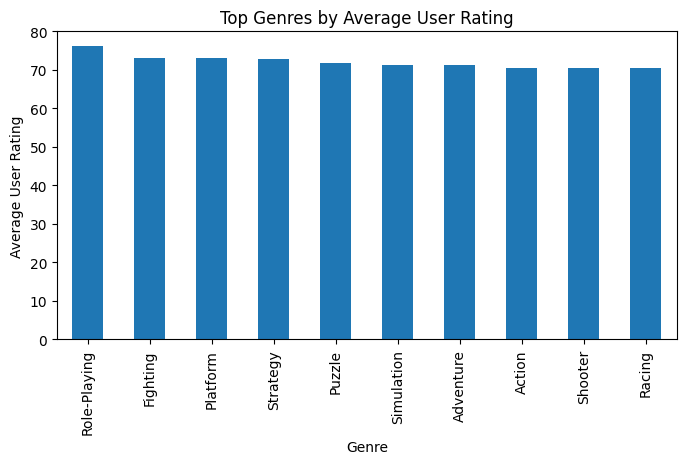

In [15]:
def mean_rating_by(col, min_games=50):
    grp = (
        df.dropna(subset=['User_Rating'])
          .groupby(col)['User_Rating']
          .agg(['mean', 'count'])
          .sort_values('mean', ascending=False)
    )
    # Filter to categories with enough games
    grp = grp[grp['count'] >= min_games]
    print(f"\nAverage User Rating by {col} (>= {min_games} games):")
    print(grp.head(10))
    return grp

genre_stats = mean_rating_by('Genre')
platform_stats = mean_rating_by('Platform')
age_stats = mean_rating_by('Age_Group_Targeted', min_games=50)
rating_stats = mean_rating_by('Rating', min_games=50)


genre_stats['mean'].head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top Genres by Average User Rating")
plt.ylabel("Average User Rating")
plt.show()


Dataset size: 16,719 games, with user ratings available for 7590 rows. Target: User_Rating (scaled from User_Score, 0–100) is moderately correlated with Critic_Score (0.58) and weakly related to global sales.
Numeric: critic score/count, user count, release year, regional/global sales.
Categorical: platform, genre, publisher, developer, ESRB rating, and a derived age group.
Distributions:Sales distributions are highly skewed with many low-selling games and a few big hits.
User ratings generally concentrate between about 60 and 90.
Category effects:Certain genres and platforms have higher average user ratings.
ESRB ratings map naturally into age groups (Kids/Teens/Adults), giving you a real-world analog of your previous synthetic feature.